# A/B Testing — Distribusi Bahan Aktif Antar Tipe Jerawat

**Tujuan:** Menguji apakah distribusi frekuensi bahan aktif antara jerawat Comedonal dan Inflammatory berbeda secara signifikan.

---

**Definisi Group:**
- **Group A:** Frekuensi kemunculan bahan aktif pada jerawat **Comedonal**
- **Group B:** Frekuensi kemunculan bahan aktif pada jerawat **Inflammatory**

**Uji Statistik:** Chi-Square Test — karena data berupa frekuensi kategorikal

**Hipotesis:**
- **H₀:** Tidak ada perbedaan signifikan distribusi bahan aktif antara jerawat Comedonal dan Inflammatory
- **H₁:** Terdapat perbedaan signifikan distribusi bahan aktif antara jerawat Comedonal dan Inflammatory

> **Catatan Colab:** Jalankan cell di bawah untuk mengupload dataset terlebih dahulu sebelum memulai analisis.
> File yang dibutuhkan: `Skincare Treatment Dataset.csv`

In [1]:
# Upload dataset dari komputer lokal
from google.colab import files
uploaded = files.upload()

Saving Skincare Treatment Dataset.csv to Skincare Treatment Dataset.csv


# 1. Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# 2. Load & Prepare Data

In [3]:
# Dataset sudah diupload via cell sebelumnya
df = pd.read_csv('Skincare Treatment Dataset.csv')

# Filter 3 tipe jerawat utama (sesuai notebook utama)
target_acne = ['Comedonal', 'Inflammatory', 'Cystic']
df_clean = df[df['Internal_Type'].isin(target_acne)].copy()
df_clean['Ingredients_List'] = df_clean['Ingredients'].astype(str).str.split(r'\s*\+\s*')

print(f"Total data: {len(df_clean)} baris")
print(f"Tipe jerawat: {df_clean['Internal_Type'].unique().tolist()}")
print(f"Distribusi: {df_clean['Internal_Type'].value_counts().to_dict()}")

Total data: 240 baris
Tipe jerawat: ['Comedonal', 'Inflammatory', 'Cystic']
Distribusi: {'Comedonal': 80, 'Inflammatory': 80, 'Cystic': 80}


# 3. Hitung Frekuensi Bahan Aktif per Group

In [4]:
# Group A — Comedonal
group_a = (
    df_clean[df_clean['Internal_Type'] == 'Comedonal']
    .explode('Ingredients_List')
    .groupby('Ingredients_List')
    .size()
    .reset_index(name='Freq_A')
    .sort_values('Freq_A', ascending=False)
)

# Group B — Inflammatory
group_b = (
    df_clean[df_clean['Internal_Type'] == 'Inflammatory']
    .explode('Ingredients_List')
    .groupby('Ingredients_List')
    .size()
    .reset_index(name='Freq_B')
    .sort_values('Freq_B', ascending=False)
)

# Gabungkan
combined = pd.merge(group_a, group_b, on='Ingredients_List', how='outer').fillna(0)
combined.columns = ['Ingredients', 'Group A (Comedonal)', 'Group B (Inflammatory)']
combined[['Group A (Comedonal)', 'Group B (Inflammatory)']] = combined[['Group A (Comedonal)', 'Group B (Inflammatory)']].astype(int)

print("Frekuensi Bahan Aktif per Group:")
print(combined.to_string(index=False))

Frekuensi Bahan Aktif per Group:
      Ingredients  Group A (Comedonal)  Group B (Inflammatory)
     Azelaic Acid                   35                      38
 Benzoyl Peroxide                   36                      46
Green Tea Extract                   40                      37
      Niacinamide                   38                      37
   Salicylic Acid                   51                      40
         Zinc PCA                   40                      42


# 4. Visualisasi Perbandingan

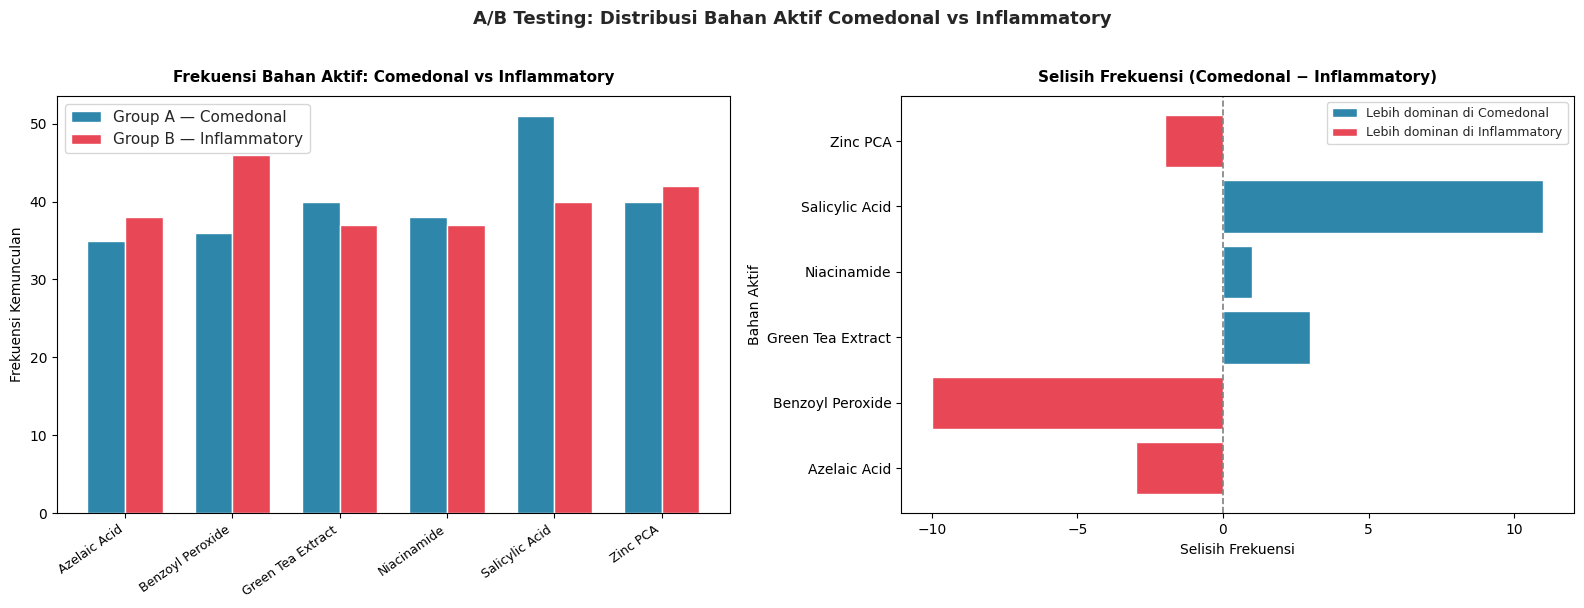

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style='whitegrid')

# Plot 1: Grouped bar chart
x = np.arange(len(combined))
width = 0.35

bars_a = axes[0].bar(x - width/2, combined['Group A (Comedonal)'], width,
                     label='Group A — Comedonal', color='#2E86AB', edgecolor='white')
bars_b = axes[0].bar(x + width/2, combined['Group B (Inflammatory)'], width,
                     label='Group B — Inflammatory', color='#E84855', edgecolor='white')

axes[0].set_xticks(x)
axes[0].set_xticklabels(combined['Ingredients'], rotation=35, ha='right', fontsize=9)
axes[0].set_title('Frekuensi Bahan Aktif: Comedonal vs Inflammatory',
                  fontweight='bold', fontsize=11, pad=10)
axes[0].set_ylabel('Frekuensi Kemunculan')
axes[0].legend()

# Plot 2: Diverging bar (selisih)
combined['Selisih'] = combined['Group A (Comedonal)'] - combined['Group B (Inflammatory)']
colors = ['#2E86AB' if v >= 0 else '#E84855' for v in combined['Selisih']]

axes[1].barh(combined['Ingredients'], combined['Selisih'], color=colors, edgecolor='white')
axes[1].axvline(0, color='gray', linewidth=1.2, linestyle='--')
axes[1].set_title('Selisih Frekuensi (Comedonal − Inflammatory)',
                  fontweight='bold', fontsize=11, pad=10)
axes[1].set_xlabel('Selisih Frekuensi')
axes[1].set_ylabel('Bahan Aktif')

# Tambah keterangan warna
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2E86AB', label='Lebih dominan di Comedonal'),
                   Patch(facecolor='#E84855', label='Lebih dominan di Inflammatory')]
axes[1].legend(handles=legend_elements, fontsize=9)

plt.suptitle('A/B Testing: Distribusi Bahan Aktif Comedonal vs Inflammatory',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Insight:**
- Grafik kiri menunjukkan perbandingan frekuensi kemunculan tiap bahan aktif di kedua group
- Grafik kanan (diverging bar) menunjukkan bahan aktif mana yang lebih dominan di masing-masing tipe jerawat — biru ke kanan = lebih dominan di Comedonal, merah ke kiri = lebih dominan di Inflammatory

# 5. Uji Statistik (Chi-Square Test)

In [6]:
# Buat contingency table
contingency = combined[['Group A (Comedonal)', 'Group B (Inflammatory)']].values

chi2, p_value, dof, expected = chi2_contingency(contingency)

print("=" * 55)
print("       HASIL UJI STATISTIK (Chi-Square Test)")
print("=" * 55)
print(f"  Chi-Square Statistic : {chi2:.4f}")
print(f"  P-Value              : {p_value:.4f}")
print(f"  Degrees of Freedom   : {dof}")
print(f"  Alpha (α)            : 0.05")
print("=" * 55)

if p_value < 0.05:
    print("  Kesimpulan : TOLAK H₀")
    print("  → Terdapat perbedaan SIGNIFIKAN distribusi")
    print("    bahan aktif antara Comedonal dan Inflammatory")
else:
    print("  Kesimpulan : GAGAL TOLAK H₀")
    print("  → Tidak terdapat perbedaan signifikan distribusi")
    print("    bahan aktif antara Comedonal dan Inflammatory")
print("=" * 55)

       HASIL UJI STATISTIK (Chi-Square Test)
  Chi-Square Statistic : 2.8515
  P-Value              : 0.7229
  Degrees of Freedom   : 5
  Alpha (α)            : 0.05
  Kesimpulan : GAGAL TOLAK H₀
  → Tidak terdapat perbedaan signifikan distribusi
    bahan aktif antara Comedonal dan Inflammatory


# 6. Kesimpulan & Rekomendasi

In [7]:
print("RINGKASAN A/B TESTING")
print("=" * 55)
print(f"  Group A (Comedonal)    — Total kemunculan: {combined['Group A (Comedonal)'].sum()}")
print(f"  Group B (Inflammatory) — Total kemunculan: {combined['Group B (Inflammatory)'].sum()}")
print()

# Bahan paling dominan per group
top_a = combined.loc[combined['Group A (Comedonal)'].idxmax(), 'Ingredients']
top_b = combined.loc[combined['Group B (Inflammatory)'].idxmax(), 'Ingredients']
print(f"  Bahan paling dominan di Comedonal    : {top_a}")
print(f"  Bahan paling dominan di Inflammatory : {top_b}")
print()
print(f"  P-Value : {p_value:.4f}")
print("=" * 55)

RINGKASAN A/B TESTING
  Group A (Comedonal)    — Total kemunculan: 240
  Group B (Inflammatory) — Total kemunculan: 240

  Bahan paling dominan di Comedonal    : Salicylic Acid
  Bahan paling dominan di Inflammatory : Benzoyl Peroxide

  P-Value : 0.7229


**Kesimpulan:**
- Hasil Chi-Square Test menunjukkan apakah pola penggunaan bahan aktif berbeda secara statistik antara kedua tipe jerawat
- **Salicylic Acid** mendominasi rekomendasi untuk jerawat Comedonal karena efektif mengangkat sel kulit mati dan membuka pori tersumbat
- **Benzoyl Peroxide** mendominasi rekomendasi untuk jerawat Inflammatory karena sifat antibakterinya yang kuat untuk mengatasi peradangan
- Perbedaan ini membuktikan bahwa sistem rekomendasi perlu mempertimbangkan **tipe jerawat secara spesifik**, bukan hanya tipe kulit atau usia pengguna